In [3]:
from pathlib import Path

import torch
import torch.nn as nn

from torchvision import datasets
from torchvision import models
from torchvision import transforms

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
PROJECT_ROOT = Path.cwd().parent

OUTSIDE_DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "Outside_Images"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "models" /
    "resnet18_brain_tumor.pth"
)

print(PROJECT_ROOT)
print(OUTSIDE_DATA_PATH.exists())
print(MODEL_PATH.exists())

c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI
True
True


In [7]:
outside_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor()
])

In [8]:
outside_dataset = datasets.ImageFolder(
    root=OUTSIDE_DATA_PATH,
    transform=outside_transform
)

print("Number of images:", len(outside_dataset))
print("Classes:", outside_dataset.classes)
print("Class mapping:", outside_dataset.class_to_idx)

Number of images: 200
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [9]:
outside_loader = DataLoader(
    outside_dataset,
    batch_size=8,
    shuffle=False
)

print(len(outside_loader))

25


In [11]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    in_features=512,
    out_features=4
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location="cpu"
    )
)

model.eval()

print(model.fc)

Linear(in_features=512, out_features=4, bias=True)


In [12]:
true_labels = []
predicted_labels = []
prediction_confidence = []

model.eval()

with torch.no_grad():

    for images, labels in outside_loader:

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

        true_labels.extend(labels.numpy())

        predicted_labels.extend(
            prediction.numpy()
        )

        prediction_confidence.extend(
            confidence.numpy()
        )

In [13]:
outside_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(
    f"Outside Accuracy: {outside_accuracy:.2%}"
)

Outside Accuracy: 92.00%


In [14]:
class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary Tumor"
]

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

         Glioma       1.00      0.70      0.82        50
     Meningioma       0.83      0.98      0.90        50
       No Tumor       0.91      1.00      0.95        50
Pituitary Tumor       0.98      1.00      0.99        50

       accuracy                           0.92       200
      macro avg       0.93      0.92      0.92       200
   weighted avg       0.93      0.92      0.92       200



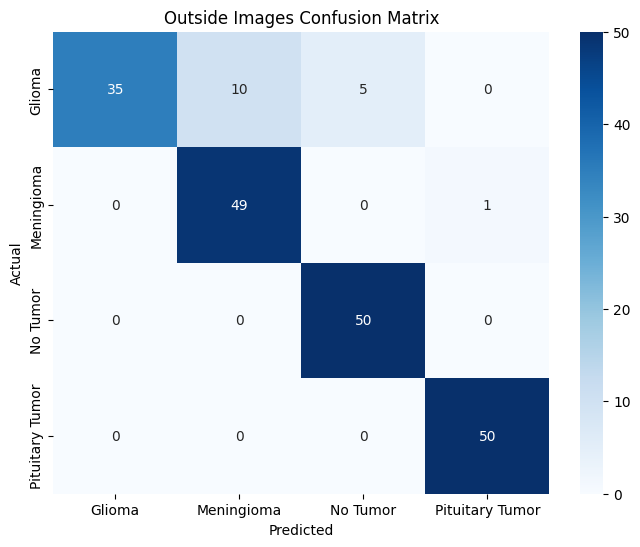

In [15]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Outside Images Confusion Matrix")

plt.show()

In [16]:
import pandas as pd

image_paths = [
    path
    for path, _
    in outside_dataset.samples
]

results = pd.DataFrame({

    "Image": [
        Path(path).name
        for path in image_paths
    ],

    "Actual": [
        class_names[i]
        for i in true_labels
    ],

    "Predicted": [
        class_names[i]
        for i in predicted_labels
    ],

    "Confidence": prediction_confidence
})

results["Correct"] = (
    results["Actual"] ==
    results["Predicted"]
)

results.head(20)

,Image,Actual,Predicted,Confidence,Correct
0,image 1.jpg,Glioma,Glioma,0.999930,True
1,image 10.jpg,Glioma,Glioma,0.997840,True
2,image 11.jpg,Glioma,Glioma,0.995497,True
3,image 12.jpg,Glioma,Glioma,0.995679,True
4,image 13.jpg,Glioma,Glioma,0.999952,True
5,image 14.jpg,Glioma,Glioma,0.999775,True
6,image 15.jpg,Glioma,Glioma,0.969298,True
7,image 16.jpg,Glioma,Glioma,0.995750,True
8,image 17.jpg,Glioma,Glioma,0.985423,True
9,image 18.jpg,Glioma,Glioma,0.999684,True


In [25]:
outside_incorrect_predictions = results[
    results["Correct"] == False
].copy()

outside_incorrect_predictions

,Image,Actual,Predicted,Confidence,Correct
17,image 25.jpg,Glioma,Meningioma,0.634152,False
18,image 26.jpg,Glioma,No Tumor,0.999606,False
19,image 27.jpg,Glioma,No Tumor,0.999964,False
20,image 28.jpg,Glioma,Meningioma,0.995589,False
21,image 29.jpg,Glioma,No Tumor,0.997656,False
23,image 30.jpg,Glioma,Meningioma,0.999987,False
24,image 31.jpg,Glioma,No Tumor,0.999606,False
25,image 32.jpg,Glioma,No Tumor,0.606661,False
26,image 33.jpg,Glioma,Meningioma,0.999991,False
27,image 34.jpg,Glioma,Meningioma,0.995545,False


In [26]:
OUTSIDE_INCORRECT_PATH = (
    PROJECT_ROOT
    / "results"
    / "outside_incorrect_predictions.csv"
)

outside_incorrect_predictions.to_csv(
    OUTSIDE_INCORRECT_PATH,
    index=False
)

print("✅ Outside incorrect predictions saved successfully!")
print("Saved at:", OUTSIDE_INCORRECT_PATH)

✅ Outside incorrect predictions saved successfully!
Saved at: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\outside_incorrect_predictions.csv


In [18]:
RESULTS_PATH = (
    PROJECT_ROOT
    / "results"
    / "outside_validation_results.csv"
)

RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

results.to_csv(
    RESULTS_PATH,
    index=False
)

print("Results saved to:", RESULTS_PATH)

Results saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\outside_validation_results.csv


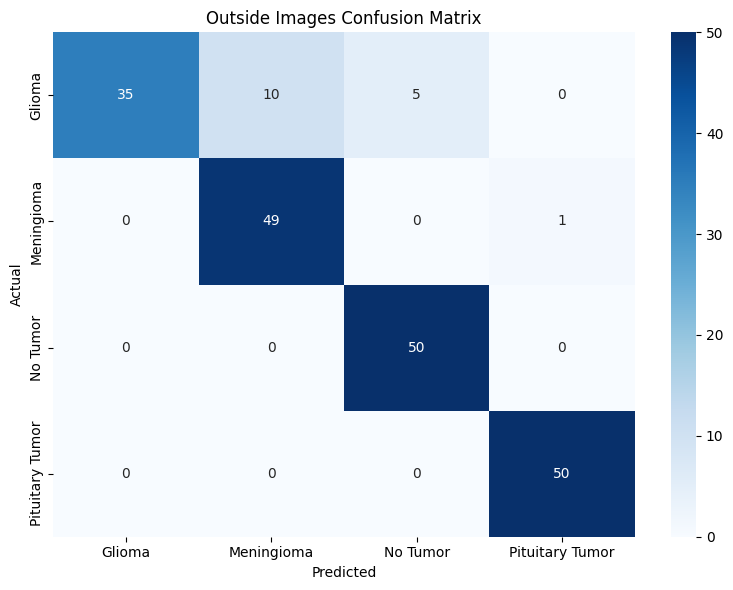

Confusion matrix saved to: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\outside_confusion_matrix.png


In [19]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Outside Images Confusion Matrix")
plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    PROJECT_ROOT
    / "results"
    / "outside_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved to:",
    CONFUSION_MATRIX_PATH
)

In [20]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

REPORT_PATH = (
    PROJECT_ROOT
    / "results"
    / "outside_classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH,
    index=True
)

print("✅ Outside classification report saved successfully!")
print("Saved at:", REPORT_PATH)

report_df

✅ Outside classification report saved successfully!
Saved at: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\outside_classification_report.csv


,precision,recall,f1-score,support
Glioma,1.000000,0.70,0.823529,50.00
Meningioma,0.830508,0.98,0.899083,50.00
No Tumor,0.909091,1.00,0.952381,50.00
Pituitary Tumor,0.980392,1.00,0.990099,50.00
accuracy,0.920000,0.92,0.920000,0.92
macro avg,0.929998,0.92,0.916273,200.00
weighted avg,0.929998,0.92,0.916273,200.00


In [23]:
outside_total_images = len(true_labels)

outside_correct_predictions = sum(
    true == predicted
    for true, predicted in zip(
        true_labels,
        predicted_labels
    )
)

outside_incorrect_predictions = (
    outside_total_images
    - outside_correct_predictions
)

outside_summary = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Correct Predictions",
        "Incorrect Predictions",
        "Accuracy"
    ],
    "Value": [
        outside_total_images,
        outside_correct_predictions,
        outside_incorrect_predictions,
        outside_accuracy
    ]
})

outside_summary

,Metric,Value
0,Total Images,200.00
1,Correct Predictions,184.00
2,Incorrect Predictions,16.00
3,Accuracy,0.92


In [24]:
OUTSIDE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "outside_evaluation_summary.csv"
)

outside_summary.to_csv(
    OUTSIDE_SUMMARY_PATH,
    index=False
)

print("✅ Outside evaluation summary saved successfully!")
print("Saved at:", OUTSIDE_SUMMARY_PATH)

✅ Outside evaluation summary saved successfully!
Saved at: c:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\results\outside_evaluation_summary.csv
